# Imports & HelperFuncs

In [1]:
from testFuncs import load_dataset_df
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from scipy.stats import wilcoxon
base_path = base_img_path = "../memoriaLatex"

In [2]:
from pathlib import Path
from functools import lru_cache

@lru_cache
def n_instances(ds, dataset_root=Path("dataset")):
    return load_dataset_df(
        dataset=ds,
        noise_type="data_base",
        split="cc",
        encoding=None,
        root=dataset_root,
    ).shape[0]

def get_available_datasets(dataset_root=Path("dataset"), n=None, reverse=False):
    base_dir = dataset_root / "data_base"
    datasets = sorted(
        [p.name for p in base_dir.iterdir() if p.is_dir()],
        key=lambda ds: (n_instances(ds, dataset_root), ds),
        reverse=reverse,
    )
    return datasets if n is None else datasets[:n]
    
keel_datasets = get_available_datasets(Path("dataset"), n=30)
print(keel_datasets)

['zoo', 'hayes-roth', 'lymphography', 'iris', 'autos', 'wine', 'sonar', 'glass', 'newthyroid', 'heart', 'cleveland', 'splice', 'ecoli', 'ionosphere', 'dermatology', 'monk-2', 'led7digit', 'wdbc', 'balance', 'pima', 'vehicle', 'vowel', 'german', 'flare', 'nursery', 'contraceptive', 'yeast', 'car', 'shuttle', 'segment']


# Simulations

In [ ]:
# import numpy as np

# from sklearn.base import clone
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.linear_model import LogisticRegression, SGDClassifier
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.preprocessing import StandardScaler
# from sklearn.naive_bayes import GaussianNB
# from sklearn.metrics import balanced_accuracy_score
# from tqdm.auto import tqdm

# from filters import *
# from filters.noiseScoreFiltering import NoiseScoreFilter

# import warnings

# warnings.filterwarnings("ignore")


# clf = LogisticRegression()

# # Fixed dataset loading config.
# fixed_dataset_info = {
#     "noise_type": "cla_rand",
#     "encoding": "onehot",
# }


# base_estimators = [
#     ("DT", DecisionTreeClassifier(
#         criterion="entropy",
#         splitter="best",
#         random_state=33
#     )),

#     ("KNN1", KNeighborsClassifier(
#         n_neighbors=3
#     )),

#     ("LR", LogisticRegression(
#         max_iter=1000,
#         random_state=33
#     )),

#     ("GNB", GaussianNB()),

#     ("DT_SMALL", DecisionTreeClassifier(
#         criterion="gini",
#         splitter="best",
#         max_depth=5,
#         min_samples_leaf=2,
#         random_state=33
#     )),

#     ("SGD_LOG", SGDClassifier(
#         loss="log_loss",
#         max_iter=1000,
#         tol=1e-3,
#         random_state=33
#     )),
# ]

# # Base filters that expose noise_score_.
# base_filters = {
#     "ENN": ENNFilter(n_neighbors=9, action="detect"),
#     "ENNProb": ENNProbFilter(n_neighbors=9, action="detect"),
#     "NCNEdit": NCNEdit(n_neighbors=9, action="detect"),
#     "EF" : EnsembleFiltering(
#                 estimators=[est for _, est in base_estimators],
#                 cv=10,
#                 mode="threshold",
#                 threshold = 0.8,
#                 action="remove",
#                 random_state=33,
#             )
# }

# # Noise-score-based filters.
# fef_configs = {
#     "fef_consensus_": dict(strategy="consensus"),
#     "fef_majority_": dict(strategy="majority"),
#     "fef_union_": dict(strategy="union"),
#     # "fef_threshold_0.2": dict(strategy="threshold", vote_threshold=0.2),
#     "fef_wThreshold_0.5": dict(strategy="weighted_threshold", score_threshold=0.5),
#     "fef_wThreshold_0.7": dict(strategy="weighted_threshold", score_threshold=0.7),
# }


# results = {
#     "dataset_id": [],
#     "fold_id": [],
#     "filter_id": [],
#     "seed" : [],
#     "noise_k": [],
#     "bal_acc": [],
# }

# seeds = [1,2,3,4,5]
# for noise_k in [5, 25, 50]:
#     for seed_k in seeds:
#         for ds_idx, dataset in enumerate(tqdm(keel_datasets[:30])):
#             print(f"noise:{noise_k}%, (ds_idx:{ds_idx},{dataset}), seed:{seed_k}")
#             for base_filter_name, base_filter in base_filters.items():
#                 for fold_idx in range(1, 6):
#                     train_fold_ds = load_dataset_df(
#                         dataset=dataset,
#                         split="tra",
#                         fold=fold_idx,
#                         k=noise_k,
#                         seed=seed_k,
#                         **fixed_dataset_info,
#                     )
#                     test_fold_ds = load_dataset_df(
#                         dataset=dataset,
#                         split="tst",
#                         fold=fold_idx,
#                         k=noise_k,
#                         seed=seed_k,
#                         **fixed_dataset_info,
#                     )

#                     X_tr = train_fold_ds.iloc[:, :-1]
#                     y_tr = train_fold_ds.iloc[:, -1]
#                     X_ts = test_fold_ds.iloc[:, :-1]
#                     y_ts = test_fold_ds.iloc[:, -1]

#                     X_tr_np = X_tr.to_numpy()
#                     X_ts_np = X_ts.to_numpy()
#                     y_tr_np = y_tr.to_numpy() if hasattr(y_tr, "to_numpy") else np.asarray(y_tr)
#                     y_ts_np = y_ts.to_numpy() if hasattr(y_ts, "to_numpy") else np.asarray(y_ts)

#                     # Scale before filtering.
#                     sc = StandardScaler()
#                     X_tr_sc = sc.fit_transform(X_tr_np)
#                     X_ts_sc = sc.transform(X_ts_np)

#                     # 1) Baseline without filtering.
#                     model = clone(clf)
#                     model.fit(X_tr_sc, y_tr_np)

#                     results["dataset_id"].append(dataset)
#                     results["fold_id"].append(fold_idx)
#                     results["seed"].append(seed_k)
#                     results["filter_id"].append("None")
#                     results["noise_k"].append(noise_k)
#                     results["bal_acc"].append(
#                         balanced_accuracy_score(y_ts_np, model.predict(X_ts_sc))
#                     )

#                     # Fit base_filters
#                     prefitted_base_filters = []
#                     for base_filter_name, base_filter in base_filters.items():
#                         fitted_base_filter = clone(base_filter)
#                         fitted_base_filter.fit(X_tr_sc, y_tr_np)
#                         prefitted_base_filters.append((base_filter_name, fitted_base_filter))

#                     # 4) FEFfilters on scaled data.
#                     for fef_name, fef_kwargs in fef_configs.items():
#                         fef = FilterEnsembleFilter(
#                             base_filters=prefitted_base_filters,
#                             refit_base_filters=False,
#                             use_filter_scores=True,
#                             normalize_scores=False,
#                             **fef_kwargs,
#                         )

#                         X_tr_f, y_tr_f = fef.fit_resample(X_tr_sc, y_tr_np)

#                         if np.unique(y_tr_f).size < 2:
#                             results["dataset_id"].append(dataset)
#                             results["fold_id"].append(fold_idx)
#                             results["seed"].append(seed_k)
#                             results["filter_id"].append(f"{fef_name}")
#                             results["noise_k"].append(noise_k)
#                             results["bal_acc"].append(np.nan)
#                             continue

#                         model = clone(clf)
#                         model.fit(X_tr_f, y_tr_f)

#                         results["dataset_id"].append(dataset)
#                         results["fold_id"].append(fold_idx)
#                         results["seed"].append(seed_k)
#                         results["filter_id"].append(f"{fef_name}")
#                         results["noise_k"].append(noise_k)
#                         results["bal_acc"].append(
#                             balanced_accuracy_score(y_ts_np, model.predict(X_ts_sc))
#                         )
#             pickle.dump(results, open(f"./results/proposalEvaluation/cla_rand/{noise_k}/seed0{seed_k}/logReg/fef.pkl", "wb"))

  0%|          | 0/30 [00:00<?, ?it/s]

noise:5%, (ds_idx:0,zoo), seed:1
noise:5%, (ds_idx:1,hayes-roth), seed:1
noise:5%, (ds_idx:2,lymphography), seed:1
noise:5%, (ds_idx:3,iris), seed:1
noise:5%, (ds_idx:4,autos), seed:1
noise:5%, (ds_idx:5,wine), seed:1
noise:5%, (ds_idx:6,sonar), seed:1
noise:5%, (ds_idx:7,glass), seed:1
noise:5%, (ds_idx:8,newthyroid), seed:1
noise:5%, (ds_idx:9,heart), seed:1
noise:5%, (ds_idx:10,cleveland), seed:1
noise:5%, (ds_idx:11,splice), seed:1
noise:5%, (ds_idx:12,ecoli), seed:1
noise:5%, (ds_idx:13,ionosphere), seed:1
noise:5%, (ds_idx:14,dermatology), seed:1
noise:5%, (ds_idx:15,monk-2), seed:1
noise:5%, (ds_idx:16,led7digit), seed:1
noise:5%, (ds_idx:17,wdbc), seed:1
noise:5%, (ds_idx:18,balance), seed:1
noise:5%, (ds_idx:19,pima), seed:1
noise:5%, (ds_idx:20,vehicle), seed:1
noise:5%, (ds_idx:21,vowel), seed:1
noise:5%, (ds_idx:22,german), seed:1
noise:5%, (ds_idx:23,flare), seed:1
noise:5%, (ds_idx:24,nursery), seed:1
noise:5%, (ds_idx:25,contraceptive), seed:1
noise:5%, (ds_idx:26,yeast)

  0%|          | 0/30 [00:00<?, ?it/s]

noise:5%, (ds_idx:0,zoo), seed:2
noise:5%, (ds_idx:1,hayes-roth), seed:2
noise:5%, (ds_idx:2,lymphography), seed:2
noise:5%, (ds_idx:3,iris), seed:2
noise:5%, (ds_idx:4,autos), seed:2
noise:5%, (ds_idx:5,wine), seed:2
noise:5%, (ds_idx:6,sonar), seed:2
noise:5%, (ds_idx:7,glass), seed:2
noise:5%, (ds_idx:8,newthyroid), seed:2
noise:5%, (ds_idx:9,heart), seed:2
noise:5%, (ds_idx:10,cleveland), seed:2
noise:5%, (ds_idx:11,splice), seed:2
noise:5%, (ds_idx:12,ecoli), seed:2
noise:5%, (ds_idx:13,ionosphere), seed:2
noise:5%, (ds_idx:14,dermatology), seed:2
noise:5%, (ds_idx:15,monk-2), seed:2
noise:5%, (ds_idx:16,led7digit), seed:2
noise:5%, (ds_idx:17,wdbc), seed:2
noise:5%, (ds_idx:18,balance), seed:2
noise:5%, (ds_idx:19,pima), seed:2
noise:5%, (ds_idx:20,vehicle), seed:2
noise:5%, (ds_idx:21,vowel), seed:2
noise:5%, (ds_idx:22,german), seed:2
noise:5%, (ds_idx:23,flare), seed:2
noise:5%, (ds_idx:24,nursery), seed:2
noise:5%, (ds_idx:25,contraceptive), seed:2
noise:5%, (ds_idx:26,yeast)

  0%|          | 0/30 [00:00<?, ?it/s]

...

noise:50%, (ds_idx:0,zoo), seed:3
noise:50%, (ds_idx:1,hayes-roth), seed:3
noise:50%, (ds_idx:2,lymphography), seed:3
noise:50%, (ds_idx:3,iris), seed:3
noise:50%, (ds_idx:4,autos), seed:3
noise:50%, (ds_idx:5,wine), seed:3
noise:50%, (ds_idx:6,sonar), seed:3
noise:50%, (ds_idx:7,glass), seed:3
noise:50%, (ds_idx:8,newthyroid), seed:3
noise:50%, (ds_idx:9,heart), seed:3
noise:50%, (ds_idx:10,cleveland), seed:3
noise:50%, (ds_idx:11,splice), seed:3
noise:50%, (ds_idx:12,ecoli), seed:3
noise:50%, (ds_idx:13,ionosphere), seed:3
noise:50%, (ds_idx:14,dermatology), seed:3
noise:50%, (ds_idx:15,monk-2), seed:3
noise:50%, (ds_idx:16,led7digit), seed:3
noise:50%, (ds_idx:17,wdbc), seed:3
noise:50%, (ds_idx:18,balance), seed:3
noise:50%, (ds_idx:19,pima), seed:3
noise:50%, (ds_idx:20,vehicle), seed:3
noise:50%, (ds_idx:21,vowel), seed:3
noise:50%, (ds_idx:22,german), seed:3
noise:50%, (ds_idx:23,flare), seed:3
noise:50%, (ds_idx:24,nursery), seed:3
noise:50%, (ds_idx:25,contraceptive), seed:3
n

  0%|          | 0/30 [00:00<?, ?it/s]

noise:50%, (ds_idx:0,zoo), seed:4
noise:50%, (ds_idx:1,hayes-roth), seed:4
noise:50%, (ds_idx:2,lymphography), seed:4
noise:50%, (ds_idx:3,iris), seed:4
noise:50%, (ds_idx:4,autos), seed:4
noise:50%, (ds_idx:5,wine), seed:4
noise:50%, (ds_idx:6,sonar), seed:4
noise:50%, (ds_idx:7,glass), seed:4
noise:50%, (ds_idx:8,newthyroid), seed:4
noise:50%, (ds_idx:9,heart), seed:4
noise:50%, (ds_idx:10,cleveland), seed:4
noise:50%, (ds_idx:11,splice), seed:4
noise:50%, (ds_idx:12,ecoli), seed:4
noise:50%, (ds_idx:13,ionosphere), seed:4
noise:50%, (ds_idx:14,dermatology), seed:4
noise:50%, (ds_idx:15,monk-2), seed:4
noise:50%, (ds_idx:16,led7digit), seed:4
noise:50%, (ds_idx:17,wdbc), seed:4
noise:50%, (ds_idx:18,balance), seed:4
noise:50%, (ds_idx:19,pima), seed:4
noise:50%, (ds_idx:20,vehicle), seed:4
noise:50%, (ds_idx:21,vowel), seed:4
noise:50%, (ds_idx:22,german), seed:4
noise:50%, (ds_idx:23,flare), seed:4
noise:50%, (ds_idx:24,nursery), seed:4
noise:50%, (ds_idx:25,contraceptive), seed:4
n

  0%|          | 0/30 [00:00<?, ?it/s]

noise:50%, (ds_idx:0,zoo), seed:5
noise:50%, (ds_idx:1,hayes-roth), seed:5
noise:50%, (ds_idx:2,lymphography), seed:5
noise:50%, (ds_idx:3,iris), seed:5
noise:50%, (ds_idx:4,autos), seed:5
noise:50%, (ds_idx:5,wine), seed:5
noise:50%, (ds_idx:6,sonar), seed:5
noise:50%, (ds_idx:7,glass), seed:5
noise:50%, (ds_idx:8,newthyroid), seed:5
noise:50%, (ds_idx:9,heart), seed:5
noise:50%, (ds_idx:10,cleveland), seed:5
noise:50%, (ds_idx:11,splice), seed:5
noise:50%, (ds_idx:12,ecoli), seed:5
noise:50%, (ds_idx:13,ionosphere), seed:5
noise:50%, (ds_idx:14,dermatology), seed:5
noise:50%, (ds_idx:15,monk-2), seed:5
noise:50%, (ds_idx:16,led7digit), seed:5
noise:50%, (ds_idx:17,wdbc), seed:5
noise:50%, (ds_idx:18,balance), seed:5
noise:50%, (ds_idx:19,pima), seed:5
noise:50%, (ds_idx:20,vehicle), seed:5
noise:50%, (ds_idx:21,vowel), seed:5
noise:50%, (ds_idx:22,german), seed:5
noise:50%, (ds_idx:23,flare), seed:5
noise:50%, (ds_idx:24,nursery), seed:5
noise:50%, (ds_idx:25,contraceptive), seed:5
n

In [3]:
noise_ks = [5,25,50]
seed_ks = [1,2,3,4,5]

# Cargo resultados filtros base
r = pd.DataFrame(pickle.load(open(f"./results/nsBased.pkl", "rb")))
r = r[r.filter_id.isin(["ENN", "ENNProb", "NCNEdit", "EF"])]

results = pd.concat([pd.DataFrame(pickle.load(open(f"./results/proposalEvaluation/cla_rand/{noise_ks[-1]}/seed0{seed_ks[-1]}/logReg/fef.pkl", "rb"))),r], axis=0)


# Agrego por 5CV (agrego sobre los folds)
res = results.\
    groupby(["dataset_id", "seed", "filter_id", "noise_k"]).\
        mean().\
    reset_index().\
    drop("fold_id", axis=1)

# Extraigo BalAcc_baseline para cada dataset,seed,noise_k
baseline_res = (
    res[res["filter_id"] == "None"]
    .drop(columns=["filter_id"])
    .rename(columns={"bal_acc": "baseline_bal_acc"})
)
# Añado a cada fila el BalAcc_baseline
res = res.merge(
    baseline_res,
    on=["dataset_id", "seed", "noise_k"],
    how="left",
)

res["bal_acc_diff"] = (res["bal_acc"] - res["baseline_bal_acc"]) * 100
res["base_filter"] = res["filter_id"].str.split("_").str[0]


# Agrego por cada semilla
res = res.\
    groupby(["dataset_id","filter_id", "noise_k", "base_filter"]).\
        mean().\
    reset_index().\
    drop("seed", axis=1)

# Agrego sobre todos los datasets
out = res.\
    drop("dataset_id", axis=1).\
    groupby(["filter_id", "noise_k", "base_filter"]).\
        mean().\
    reset_index()
out

,filter_id,noise_k,base_filter,bal_acc,baseline_bal_acc,bal_acc_diff
0,EF,5,EF,0.736142,0.730079,0.606341
1,EF,25,EF,0.710053,0.678374,3.167958
2,EF,50,EF,0.660798,0.621255,3.954279
3,ENN,5,ENN,0.688272,0.730079,-4.180716
4,ENN,25,ENN,0.677022,0.678374,-0.135141
5,ENN,50,ENN,0.644404,0.621255,2.314823
6,ENNProb,5,ENNProb,0.705478,0.730079,-2.460051
7,ENNProb,25,ENNProb,0.689248,0.678374,1.087418
8,ENNProb,50,ENNProb,0.653418,0.621255,3.216271
9,NCNEdit,5,NCNEdit,0.697911,0.730079,-3.216825


In [4]:
results.filter_id.unique()

array(['None', 'fef_consensus_', 'fef_majority_', 'fef_union_',
       'fef_threshold_0.7', 'fef_wThreshold_0.5', 'fef_wThreshold_0.7',
       'ENN', 'ENNProb', 'NCNEdit', 'EF'], dtype=object)

In [5]:
from scipy.stats import wilcoxon

# Agrego por tipo de filtro, nivel de ruido sobre todos los datasets
out = (
    res[res["filter_id"] != "None"]
    .groupby(["noise_k", "filter_id", ], as_index=False)["bal_acc_diff"]
    .mean()
    .sort_values(["noise_k", "bal_acc_diff"], ascending=[True, False])
)
out["p_value"] = out.apply(lambda row: wilcoxon(res[(res.noise_k==row["noise_k"])&(res.filter_id==row.filter_id)].bal_acc_diff, alternative="greater").pvalue, axis=1)

out

,noise_k,filter_id,bal_acc_diff,p_value
9,5,fef_wThreshold_0.7,1.309372,0.001872
4,5,fef_consensus_,0.855359,0.067368
0,5,EF,0.606341,0.174606
8,5,fef_wThreshold_0.5,0.423016,0.451613
5,5,fef_majority_,-0.613550,0.701096
6,5,fef_threshold_0.7,-0.613550,0.701096
7,5,fef_union_,-2.409923,0.978674
2,5,ENNProb,-2.460051,0.968222
3,5,NCNEdit,-3.216825,0.998720
1,5,ENN,-4.180716,0.999481


In [8]:
# from scipy.stats import wilcoxon
# from statsmodels.stats.multitest import multipletests

# bf_dfs = {bf_name : (
#     res[res["filter_id"] == bf_name]
#     .drop(columns=["filter_id"])
#     .rename(columns={"bal_acc": f"{bf_name}_bal_acc"})
# ) for bf_name in ["None", "EF", "NCNEdit", "ENN", "ENNProb"]}

# for bf_name in bf_dfs.keys():
#     res = res.merge(
#         bf_dfs[bf_name][["dataset_id", "noise_k", f"{bf_name}_bal_acc"]],
#         on=["dataset_id", "noise_k"],
#         how="left",
#     )

#     res[f"bal_acc_diff_to_{bf_name}"] = (res["bal_acc"] - res[f"{bf_name}_bal_acc"]) * 100


# out = (
#     res[res["filter_id"] != "None"]
#     .groupby(["noise_k", "filter_id"], as_index=False)[[f"bal_acc_diff_to_{bf_name}" for bf_name in bf_dfs.keys()]]
#     .mean()
# )
# for bf_name in bf_dfs.keys():
#     out[f"wilcox_greater_to_{bf_name}"] = out.apply(lambda row: wilcoxon(res[(res.noise_k==row["noise_k"])&(res.filter_id==row.filter_id)][f"bal_acc_diff_to_{bf_name}"], alternative="greater").pvalue, axis=1)
# bacdif_keys = [f"wilcox_greater_to_{bf_name}" for bf_name in list(bf_dfs.keys())[1:]]
# out[bacdif_keys] = out[bacdif_keys].apply(
#     func=lambda row: 
#         multipletests(
#             row.to_numpy(),
#             alpha=0.05,
#             method="holm"   # bonferroni, holm, sidak, fdr_bh, fdr_by...
#         )[1],
#     axis=0
# )
# out = out.\
#     drop([f"bal_acc_diff_to_{bf_name}" for bf_name in list(bf_dfs.keys())[1:]], axis=1).\
#     rename({"bal_acc_diff_to_None":"bal_acc_diff", "wilcox_greater_to_None":"p_value"}, axis=1)
# out.sort_values(["noise_k", "bal_acc_diff"], ascending=[True, False])

In [9]:
tabla = (
    out.pivot_table(
        index=["filter_id"],
        columns="noise_k",
        values=["bal_acc_diff", "p_value"],
    )
)
# media de las 3 columnas de bal_acc_diff
tabla["_mean_bal_acc_diff"] = tabla["bal_acc_diff"].mean(axis=1)

# ordenar por esa media
tabla = tabla.sort_values("_mean_bal_acc_diff", ascending=False)
tabla

bal_acc_diff                       p_value            \
noise_k                       5        25        50         5        25   
filter_id                                                                 
fef_wThreshold_0.5     0.423016  3.585530  5.233608  0.451613  0.001738   
fef_consensus_         0.855359  3.377302  4.013726  0.067368  0.000729   
EF                     0.606341  3.167958  3.954279  0.174606  0.000616   
fef_threshold_0.7     -0.613550  2.632006  4.729521  0.701096  0.020245   
fef_majority_         -0.613550  2.632006  4.729521  0.701096  0.020245   
fef_wThreshold_0.7     1.309372  3.299783  1.832822  0.001872  0.000044   
ENNProb               -2.460051  1.087418  3.216271  0.968222  0.427636   
fef_union_            -2.409923  0.784498  3.282262  0.978674  0.365171   
NCNEdit               -3.216825  0.692837  2.922727  0.998720  0.443597   
ENN                   -4.180716 -0.135141  2.314823  0.999481  0.701096   

                             _mean_bal_acc_diff  
noise_k                   50                     
filter_id                                        
fef_wThreshold_0.5  0.000209           3.080718  
fef_consensus_      0.000172           2.748796  
EF                  0.001494           2.576193  
fef_threshold_0.7   0.004651           2.249326  
fef_majority_       0.004651           2.249326  
fef_wThreshold_0.7  0.000859           2.147326  
ENNProb             0.075943           0.614546  
fef_union_          0.043969           0.552279  
NCNEdit             0.073000           0.132913  
ENN                 0.291879          -0.667011

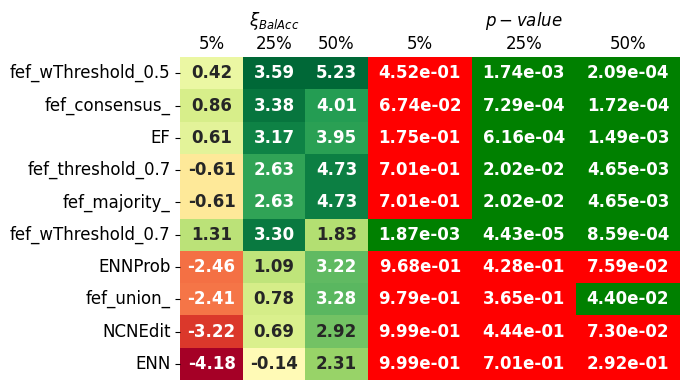

In [10]:
noise_levels = [5, 25, 50]

diff = tabla["bal_acc_diff"].copy()
pval = tabla["p_value"].copy()

# Orden según desempeño promedio en los 3 niveles
orden = diff[noise_levels].mean(axis=1).sort_values(ascending=False).index

diff = diff.loc[orden]
pval = pval.loc[orden]

fig, axes = plt.subplots(1, 6, figsize=(7, max(4, 0.35 * len(tabla))),
gridspec_kw={"width_ratios": 3*[0.6]+[ 1, 1, 1], "wspace": 0.}
)

for i, nk in enumerate(noise_levels):
    sns.heatmap(
        diff[[nk]],
        annot=True,
        fmt=".2f",
        cmap="RdYlGn",
        center=0,
        cbar=False,
        ax=axes[i],
        annot_kws={"size": 12, "weight":600},
    )
    if i==1:
        axes[i].set_title(r"$\xi_{BalAcc}$"+f"\n{nk}%")
    else:
        axes[i].set_title(f"{nk}%")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].tick_params(axis="y", rotation=0, labelsize=12)
    axes[i].set_xticks([])
    if i!=0:
        axes[i].set_yticks([])

for i, nk in enumerate(noise_levels):
    sig = (pval[[nk]] < 0.05).astype(int)
    sns.heatmap(
        sig,
        annot=pval[[nk]],
        fmt=".2e",
        cmap=sns.color_palette(["red", "green"], as_cmap=True),
        vmin=0,
        vmax=1,
        cbar=False,
        ax=axes[i + 3],
        annot_kws={"size": 12, "weight":600},
    )
    if i==1:
        axes[i+3].set_title(r"$p-value$"+f"\n{nk}%")
    else:
        axes[i+3].set_title(f"{nk}%")
    axes[i + 3].set_xlabel("")
    axes[i + 3].set_ylabel("")
    axes[i + 3].set_yticks([])
    axes[i+3].set_xticks([])

plt.tight_layout()
plt.savefig(base_path + f"/img/fefApproach/fef_performance.png")
plt.show()

Aplicando Holm:

In [6]:
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import numpy as np

# Agrego por tipo de filtro, nivel de ruido sobre todos los datasets
out = (
    res[res["filter_id"] != "None"]
    .groupby(["noise_k", "filter_id"], as_index=False)["bal_acc_diff"]
    .mean()
    .sort_values(["noise_k", "bal_acc_diff"], ascending=[True, False])
)

tests = []

for (noise_k, filter_id), g in res[res["filter_id"] != "None"].groupby(["noise_k", "filter_id"]):
    vals = g["bal_acc_diff"].dropna().to_numpy()

    if len(vals) == 0 or np.allclose(vals, 0):
        pval = np.nan
    else:
        try:
            pval = wilcoxon(vals, alternative="greater").pvalue
        except ValueError:
            pval = np.nan

    tests.append({
        "noise_k": noise_k,
        "filter_id": filter_id,
        "p_value": pval,
    })

tests_df = pd.DataFrame(tests)

tests_df["p_value_holm"] = np.nan

# Corrección de Holm por cada nivel de ruido
for noise_k, idx in tests_df.groupby("noise_k").groups.items():
    valid_idx = tests_df.loc[idx].index[tests_df.loc[idx, "p_value"].notna()]

    if len(valid_idx) > 0:
        tests_df.loc[valid_idx, "p_value_holm"] = multipletests(
            tests_df.loc[valid_idx, "p_value"],
            method="holm",
        )[1]

out = out.merge(
    tests_df[["noise_k", "filter_id", "p_value", "p_value_holm"]],
    on=["noise_k", "filter_id"],
    how="left",
)

bal_acc_diff                       p_value            \
noise_k                       5        25        50         5        25   
filter_id                                                                 
fef_wThreshold_0.5     0.423016  3.585530  5.233608  0.451613  0.001738   
fef_consensus_         0.855359  3.377302  4.013726  0.067368  0.000729   
EF                     0.606341  3.167958  3.954279  0.174606  0.000616   
fef_majority_         -0.613550  2.632006  4.729521  0.701096  0.020245   
fef_wThreshold_0.7     1.309372  3.299783  1.832822  0.001872  0.000044   
ENNProb               -2.460051  1.087418  3.216271  0.968222  0.427636   
fef_union_            -2.409923  0.784498  3.282262  0.978674  0.365171   
NCNEdit               -3.216825  0.692837  2.922727  0.998720  0.443597   
ENN                   -4.180716 -0.135141  2.314823  0.999481  0.701096   

                             p_value_holm                      \
noise_k                   50            5        25        50   
filter_id                                                       
fef_wThreshold_0.5  0.000209     1.000000  0.012163  0.001883   
fef_consensus_      0.000172     0.606308  0.005830  0.001725   
EF                  0.001494     1.000000  0.005544  0.010455   
fef_majority_       0.004651     1.000000  0.121469  0.027903   
fef_wThreshold_0.7  0.000859     0.018722  0.000443  0.006874   
ENNProb             0.075943     1.000000  1.000000  0.218999   
fef_union_          0.043969     1.000000  1.000000  0.175877   
NCNEdit             0.073000     1.000000  1.000000  0.218999   
ENN                 0.291879     1.000000  1.000000  0.291879   

                   _mean_bal_acc_diff  
noise_k                                
filter_id                              
fef_wThreshold_0.5           3.080718  
fef_consensus_               2.748796  
EF                           2.576193  
fef_majority_                2.249326  
fef_wThreshold_0.7           2.147326  
ENNProb                      0.614546  
fef_union_                   0.552279  
NCNEdit                      0.132913  
ENN                         -0.667011

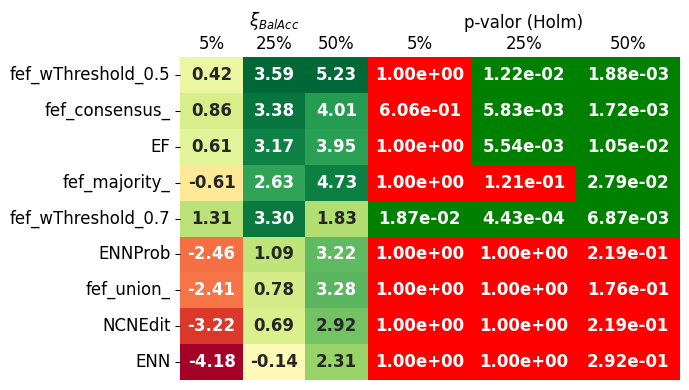

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

noise_levels = [5, 25, 50]

tabla = (
    out.pivot_table(
        index="filter_id",
        columns="noise_k",
        values=["bal_acc_diff", "p_value", "p_value_holm"],
    ).drop(index="fef_threshold_0.7")
)

# Media de las 3 columnas de bal_acc_diff para ordenar
tabla["_mean_bal_acc_diff"] = tabla["bal_acc_diff"].mean(axis=1)
tabla = tabla.sort_values("_mean_bal_acc_diff", ascending=False)

display(tabla)

diff = tabla["bal_acc_diff"].copy()
pval = tabla["p_value_holm"].copy()

# Orden según desempeño promedio en los 3 niveles
orden = diff[noise_levels].mean(axis=1).sort_values(ascending=False).index

diff = diff.loc[orden]
pval = pval.loc[orden]

fig, axes = plt.subplots(
    1,
    6,
    figsize=(7, max(4, 0.35 * len(tabla))),
    gridspec_kw={
        "width_ratios": 3 * [0.6] + [1, 1, 1],
        "wspace": 0.0,
    },
)

for i, nk in enumerate(noise_levels):
    sns.heatmap(
        diff[[nk]],
        annot=True,
        fmt=".2f",
        cmap="RdYlGn",
        center=0,
        cbar=False,
        ax=axes[i],
        annot_kws={"size": 12, "weight": 600},
    )

    if i == 1:
        axes[i].set_title(r"$\xi_{BalAcc}$" + f"\n{nk}%")
    else:
        axes[i].set_title(f"{nk}%")

    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].tick_params(axis="y", rotation=0, labelsize=12)
    axes[i].set_xticks([])

    if i != 0:
        axes[i].set_yticks([])

for i, nk in enumerate(noise_levels):
    sig = (pval[[nk]] < 0.05).astype(int)

    sns.heatmap(
        sig,
        annot=pval[[nk]],
        fmt=".2e",
        cmap=sns.color_palette(["red", "green"], as_cmap=True),
        vmin=0,
        vmax=1,
        cbar=False,
        ax=axes[i + 3],
        annot_kws={"size": 12, "weight": 600},
    )

    if i == 1:
        axes[i + 3].set_title(r"p-valor (Holm)" + f"\n{nk}%")
    else:
        axes[i + 3].set_title(f"{nk}%")

    axes[i + 3].set_xlabel("")
    axes[i + 3].set_ylabel("")
    axes[i + 3].set_yticks([])
    axes[i + 3].set_xticks([])

plt.tight_layout()
plt.savefig(base_path + "/img/fefApproach/fef_performance.png")
plt.show()